# 实验一：Regression Analysis
## 1、实验内容

- 使用神经网络模型预测混凝土的抗压强度，掌握回归问题的深度学习流程。
  
## 2、实验环境

- 编程语言: Python 3.10

- 深度学习框架: PyTorch

- 数据处理: Pandas, NumPy

- 可视化: Matplotlib, Seaborn

- 数据预处理: Scikit-learn


## 3、实验数据

- 该数据为混凝土抗压强度数据，共1030实例
- 8输入变量，1输出变量。
- Columns:
- - Cement (component 1) ：kg in a m3 mixture -- Input Variable
  - Blast Furnace Slag (component 2)：kg in a m3 mixture -- Input Variable
  - Fly Ash (component 3)：kg in a m3 mixture -- Input Variable
  - Water (component 4)：kg in a m3 mixture -- Input Variable
  - Superplasticizer (component 5)：kg in a m3 mixture -- Input Variable
  - Coarse Aggregate (component 6)：kg in a m3 mixture -- Input Variable
  - Fine Aggregate (component 7)：kg in a m3 mixture -- Input Variable
  - Age：Day (1~365) -- Input Variable
  - Concrete compressive strength：MPa -- Output Variable

## 4、实验步骤与结果分析

In [1]:
# 1）导入实验数据
import pandas as pd
data = pd.read_csv("Concrete_Data_Yeh.csv")
data.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


- 数据加载成功，共8个输入特征和1个输出目标

- 数据中存在多种不同的混凝土配比组合

- 各特征数值范围差异较大（如水泥540kg，水162kg），需要进行标准化处理

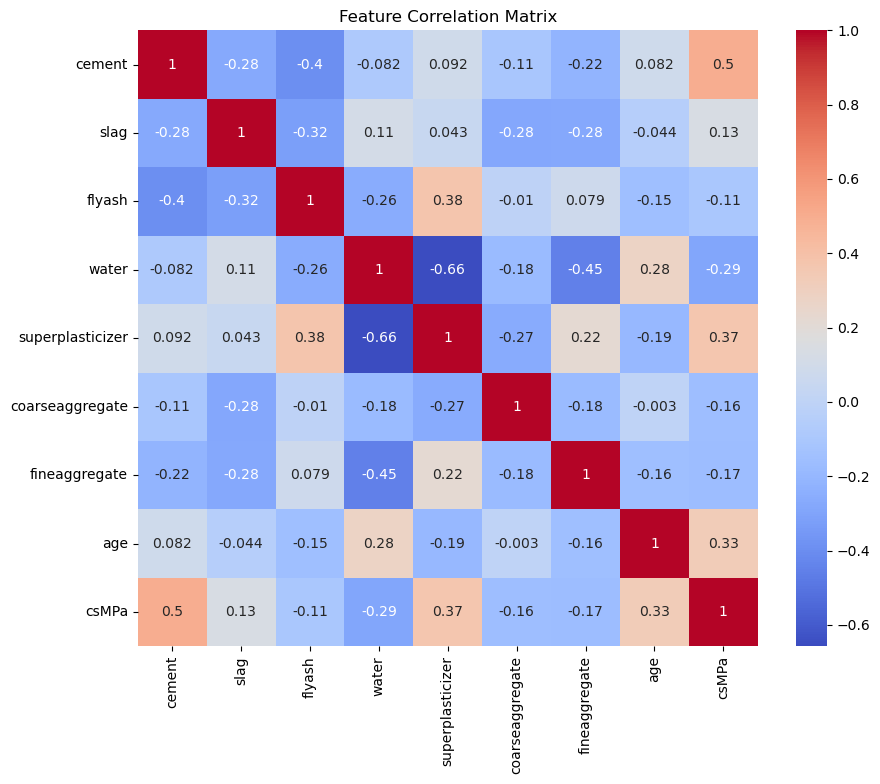

In [2]:
# 2）进行相关性分析
import seaborn as sns
import matplotlib.pyplot as plt

#相关性矩阵
corr = data.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

- 通过相关性分析可以发现，cement、superplasticizer和age与混凝土抗压强度具有较强的正相关性，而water与强度呈较强的负相关关系，因此这些特征对模型预测具有重要影响。

In [3]:
# 3）划分数据集
from sklearn.model_selection import train_test_split
X = data.iloc[:,0:8].values
y = data.iloc[:,8].values

train_size = int(0.8 * len(X))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

- 经过观察，实验数据可能是按批次采集的，相同配比的样本在多处连续出现，因此顺序划分会导致训练集和测试集的数据分布不同
- 故在数据集划分时进行随机打乱，确保模型学习到真正的特征——目标关系，而不是数据顺序模式

In [4]:
# 4）对数据进行标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- 使用Z-score标准化，将各特征转换为均值为0、标准差为1的标准正态分布
- 计算训练集每个特征的均值和标准差，并对训练集和测试集数据进行标准化

In [5]:
# 5）建立神经网络模型并进行训练
import torch
import torch.nn as nn
import torch.optim as optim
import random

X_train = torch.FloatTensor(X_train_scaled)
y_train = torch.FloatTensor(y_train).view(-1,1)

X_test = torch.FloatTensor(X_test_scaled)
y_test = torch.FloatTensor(y_test).view(-1,1)

class Net(nn.Module):

    def __init__(self):
        super(Net,self).__init__()
        self.net = nn.Sequential(
            nn.Linear(8,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Linear(16,1)
        )

    def forward(self,x):
        return self.net(x)

torch.manual_seed(42)
model = Net()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

epochs = 1000 + 1

for epoch in range(epochs):

    pred = model(X_train)

    loss = criterion(pred,y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 200 == 0:
        print(epoch,'loss =',loss.item())

0 loss = 1583.2178955078125
200 loss = 175.1939697265625
400 loss = 107.08506774902344
600 loss = 53.59735870361328
800 loss = 28.159278869628906
1000 loss = 20.325830459594727


- 模型结构：三层隐藏层，分别有64、32、16个神经元，激活函数为ReLU
- 损失下降趋势：初始损失为1583.22（非常高），损失下降迅速

In [6]:
# 6）模型
model.eval()

with torch.no_grad():
    y_pred = model(X_test)

test_loss = criterion(y_pred,y_test)

print("Test MSE:",test_loss.item())

Test MSE: 34.287620544433594


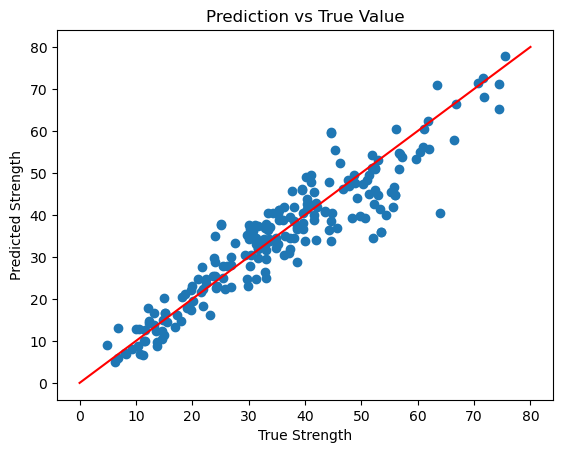

In [7]:
# 7）结果可视化
import matplotlib.pyplot as plt

y_pred = y_pred.numpy()
y_test = y_test.numpy()

plt.scatter(y_test,y_pred)

plt.xlabel("True Strength")
plt.ylabel("Predicted Strength")

plt.title("Prediction vs True Value")

plt.plot([0,80],[0,80],'r')

plt.show()

- 通过可视化结果图，可以看到预测值与真实值基本呈正相关趋势，点分布在红色参考线附近，说明预测方向正确
- 其中低强度区域预测相对准确，高强度区域（>60MPa）预测偏差较大

In [8]:
# 8）保存结果
plt.savefig("result.png")

<Figure size 640x480 with 0 Axes>

## 5、实验结论
- 水泥含量、超塑化剂和龄期是影响混凝土强度的关键因素

- 神经网络模型能够学习特征与强度之间的非线性关系，特征标准化对神经网络训练至关重要
